<a href="https://colab.research.google.com/github/maurya-ankita/privacy-preserving-federated-learning-catboost/blob/main/Federated_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# Cell 1: Install Required Libraries
# ============================================================

# Install CatBoost library for machine learning model training
!pip install -q catboost

# Install TenSEAL library for Homomorphic Encryption
# (used in the later stages of Federated Learning)
!pip install -q tenseal

# Install imbalanced-learn library for handling class imbalance
# using the SMOTE oversampling technique
!pip install -q imbalanced-learn

# Import SMOTE for synthetic oversampling of minority classes
from imblearn.over_sampling import SMOTE

# Suppress warning messages to keep the notebook output clean
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# ============================================================
# Cell 2: Import Required Libraries
# ============================================================

# ------------------------------------------------------------
# Import libraries for data manipulation
# ------------------------------------------------------------
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Import libraries for data visualization
# ------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Import machine learning libraries
# ------------------------------------------------------------
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    OrdinalEncoder
)

# ------------------------------------------------------------
# Import SMOTE for oversampling minority classes
# ------------------------------------------------------------
from imblearn.over_sampling import SMOTE

# ------------------------------------------------------------
# Import evaluation metrics
# ------------------------------------------------------------
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# Suppress warning messages
# ------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Set the plotting style
# ------------------------------------------------------------
plt.style.use("ggplot")

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [ ]:
# ============================================================
# Cell 4: Load Dataset
# ============================================================

df = pd.read_csv("medical_data1.csv")

print("✅ Dataset loaded successfully.")

✅ Dataset loaded successfully.


In [ ]:
# ============================================================
# Cell 5: Explore the Dataset
# ============================================================

# ------------------------------------------------------------
# This step provides an overview of the dataset before
# performing any preprocessing.
#
# The following information is displayed:
# • Dataset dimensions
# • First five records
# • Column names
# • Data types
# • Missing values
# • Duplicate records
# ------------------------------------------------------------

# ------------------------------------------------------------
# Display the number of rows and columns
# ------------------------------------------------------------
print("="*60)
print("Dataset Shape")
print("="*60)

print(df.shape)

print("\n")

# ------------------------------------------------------------
# Display the first five records
# ------------------------------------------------------------
print("="*60)
print("First Five Rows")
print("="*60)

display(df.head())

print("\n")

# ------------------------------------------------------------
# Display all column names
# ------------------------------------------------------------
print("="*60)
print("Column Names")
print("="*60)

print(df.columns.tolist())

print("\n")

# ------------------------------------------------------------
# Display the data type of each column
# ------------------------------------------------------------
print("="*60)
print("Data Types")
print("="*60)

print(df.dtypes)

print("\n")

# ------------------------------------------------------------
# Check for missing values
# ------------------------------------------------------------
print("="*60)
print("Missing Values")
print("="*60)

print(df.isnull().sum())

print("\n")

# ------------------------------------------------------------
# Check for duplicate records
# ------------------------------------------------------------
print("="*60)
print("Duplicate Rows")
print("="*60)

print(df.duplicated().sum())

Dataset Shape
(10000, 13)


First Five Rows


,Patient_ID,Age,Gender,Medical_Condition,Treatment,Outcome,Insurance_Type,Income,Region,Smoking_Status,Admission_Type,Hospital_ID,Length_of_Stay
0,1,18,Female,Chronic Obstructive,Therapy,Stable,Private,20841,East,Former smoker,Urgent,1,16
1,2,42,Male,Chronic Obstructive,Physical therapy,Stable,Medicare,23046,West,Non-smoker,Emergency,1,17
2,3,18,Male,Rheumatoid Arthritis,Dialysis,Improved,Private,73717,East,Non-smoker,Elective,1,11
3,4,87,Male,Asthma,Inhaler therapy,Stable,Public,27756,South,Non-smoker,Elective,1,19
4,5,66,Male,Diabetes,Bone density tests,Stable,Medicare,76571,West,Non-smoker,Emergency,1,3




Column Names
['Patient_ID', 'Age', 'Gender', 'Medical_Condition', 'Treatment', 'Outcome', 'Insurance_Type', 'Income', 'Region', 'Smoking_Status', 'Admission_Type', 'Hospital_ID', 'Length_of_Stay']


Data Types
Patient_ID            int64
Age                   int64
Gender               object
Medical_Condition    object
Treatment            object
Outcome              object
Insurance_Type       object
Income                int64
Region               object
Smoking_Status       object
Admission_Type       object
Hospital_ID           int64
Length_of_Stay        int64
dtype: object


Missing Values
Patient_ID           0
Age                  0
Gender               0
Medical_Condition    0
Treatment            0
Outcome              0
Insurance_Type       0
Income               0
Region               0
Smoking_Status       0
Admission_Type       0
Hospital_ID          0
Length_of_Stay       0
dtype: int64


Duplicate Rows
0


Outcome Distribution
Outcome
Stable      5812
Improved    2707
Worsened    1481
Name: count, dtype: int64


Outcome Percentages
Outcome
Stable      58.12
Improved    27.07
Worsened    14.81
Name: proportion, dtype: float64


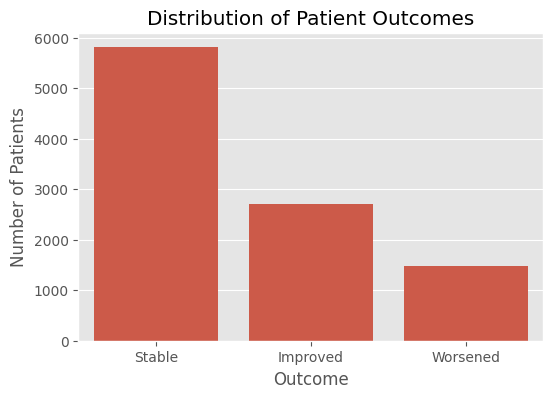

✅ The dataset is reasonably balanced.


In [ ]:
# ============================================================
# Cell 6: Analyze the Target Variable
# ============================================================

# ------------------------------------------------------------
# Analyze the distribution of the target variable (Outcome).
#
# This step helps to:
# • Identify class imbalance
# • Understand the distribution of each outcome class
# • Determine whether balancing techniques such as SMOTE
#   are required before model training.
# ------------------------------------------------------------

# ------------------------------------------------------------
# Display the number of samples in each outcome class
# ------------------------------------------------------------
print("="*60)
print("Outcome Distribution")
print("="*60)

print(df["Outcome"].value_counts())

print("\n")

# ------------------------------------------------------------
# Display the percentage of samples in each outcome class
# ------------------------------------------------------------
print("="*60)
print("Outcome Percentages")
print("="*60)

print(df["Outcome"].value_counts(normalize=True) * 100)

# ------------------------------------------------------------
# Visualize the distribution of the target variable
# ------------------------------------------------------------
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Outcome"
)

plt.title("Distribution of Patient Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.show()

# ------------------------------------------------------------
# Interpretation
# ------------------------------------------------------------

if df["Outcome"].value_counts(normalize=True).max() < 0.60:
    print("✅ The dataset is reasonably balanced.")
else:
    print("⚠️ The dataset is imbalanced. SMOTE may be considered.")

In [ ]:
# =====================================================
# Check Hospital Distribution
# =====================================================

print(df["Hospital_ID"].value_counts().sort_index())

print("\n")

print("Number of Hospitals : ", df["Hospital_ID"].nunique())

Hospital_ID
1    2000
2    2000
3    2000
4    2000
5    2000
Name: count, dtype: int64


Number of Hospitals :  5


In [ ]:
#PREPROCESSING PIPELINE
  # dropping the existing patient ID and hospital ID and then again adding hospital ID as per five hospitals.

In [ ]:
df = df.drop(columns=["Patient_ID"])

In [ ]:
df = df.drop(columns=["Hospital_ID"])

In [ ]:
label_encoder = LabelEncoder()
df["Outcome"] = label_encoder.fit_transform(df["Outcome"])

In [ ]:
df.head()

,Age,Gender,Medical_Condition,Treatment,Outcome,Insurance_Type,Income,Region,Smoking_Status,Admission_Type,Length_of_Stay
0,18,Female,Chronic Obstructive,Therapy,1,Private,20841,East,Former smoker,Urgent,16
1,42,Male,Chronic Obstructive,Physical therapy,1,Medicare,23046,West,Non-smoker,Emergency,17
2,18,Male,Rheumatoid Arthritis,Dialysis,0,Private,73717,East,Non-smoker,Elective,11
3,87,Male,Asthma,Inhaler therapy,1,Public,27756,South,Non-smoker,Elective,19
4,66,Male,Diabetes,Bone density tests,1,Medicare,76571,West,Non-smoker,Emergency,3


In [ ]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [ ]:
# ============================================================
# Cell 8: Split the Dataset into Training and Testing Sets
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Split the dataset into training (80%) and testing (20%)
#
# stratify=y ensures that all outcome classes maintain
# the same proportion in both training and testing datasets.
#
# random_state=42 ensures reproducibility.
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train-Test Split Completed Successfully")

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

Train-Test Split Completed Successfully
Training Samples : 8000
Testing Samples  : 2000


In [ ]:
# ============================================================
# Cell 9: Apply SMOTE Oversampling
# ============================================================

# ------------------------------------------------------------
# SMOTE works only with numerical features.
# Therefore, categorical variables are first converted into
# numerical values using Ordinal Encoding.
#
# IMPORTANT:
# SMOTE is applied ONLY on the training dataset.
# The testing dataset remains untouched to avoid data leakage.
# ------------------------------------------------------------

from sklearn.preprocessing import OrdinalEncoder

# Create copies of the datasets
X_train_smote = X_train.copy()
X_test_smote = X_test.copy()

# Identify categorical columns
categorical_columns = X_train_smote.select_dtypes(include="object").columns

# Initialize Ordinal Encoder
encoder = OrdinalEncoder(handle_unknown="use_encoded_value",
                         unknown_value=-1)

# Encode training data
X_train_smote[categorical_columns] = encoder.fit_transform(
    X_train_smote[categorical_columns]
)

# Encode testing data
X_test_smote[categorical_columns] = encoder.transform(
    X_test_smote[categorical_columns]
)

# ------------------------------------------------------------
# Apply SMOTE on the training dataset
# ------------------------------------------------------------

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_smote,
    y_train
)

print("SMOTE Applied Successfully")

print("\nClass Distribution After SMOTE")

print(y_train_smote.value_counts())

SMOTE Applied Successfully

Class Distribution After SMOTE
Outcome
2    4650
0    4650
1    4650
Name: count, dtype: int64


In [ ]:
# ============================================================
# Cell 10: Train the Centralized CatBoost Model
# ============================================================

# ------------------------------------------------------------
# Initialize the CatBoost classifier.
#
# Since the target variable contains three classes,
# the MultiClass loss function is used.
# ------------------------------------------------------------

catboost_model = CatBoostClassifier(

    loss_function="MultiClass",

    iterations=500,

    learning_rate=0.05,

    depth=8,

    random_seed=42,

    verbose=100

)

# ------------------------------------------------------------
# Train the model using the SMOTE-balanced training dataset.
# ------------------------------------------------------------

catboost_model.fit(

    X_train_smote,

    y_train_smote

)

print("\n✅ Centralized CatBoost Model Trained Successfully.")

0:	learn: 1.0451892	total: 53ms	remaining: 26.5s
100:	learn: 0.2711820	total: 4.18s	remaining: 16.5s
200:	learn: 0.2016465	total: 7.22s	remaining: 10.7s
300:	learn: 0.1718472	total: 10.1s	remaining: 6.68s
400:	learn: 0.1564043	total: 13s	remaining: 3.21s
499:	learn: 0.1452700	total: 17.1s	remaining: 0us

✅ Centralized CatBoost Model Trained Successfully.


In [ ]:
# ============================================================
# Cell 11: Predict Patient Outcomes
# ============================================================

# ------------------------------------------------------------
# Predict the patient outcomes for the testing dataset.
# ------------------------------------------------------------

y_pred = catboost_model.predict(X_test_smote)

print("✅ Prediction Completed Successfully.")

✅ Prediction Completed Successfully.


In [ ]:
# ============================================================
# Cell 12: Evaluate the Centralized CatBoost Model
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("=" * 60)
print("Centralized CatBoost Performance")
print("=" * 60)

print(f"Accuracy  : {accuracy:.4f}")p[]\c vbynumio,.p/['']
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

SyntaxError: invalid syntax (2609678363.py, line 29)

In [ ]:
# ============================================================
# Cell 13: Classification Report
# ============================================================

print("=" * 60)
print("Classification Report")
print("=" * 60)

print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.86      0.87       542
           1       0.89      0.89      0.89      1162
           2       0.80      0.84      0.82       296

    accuracy                           0.87      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.87      0.87      0.87      2000



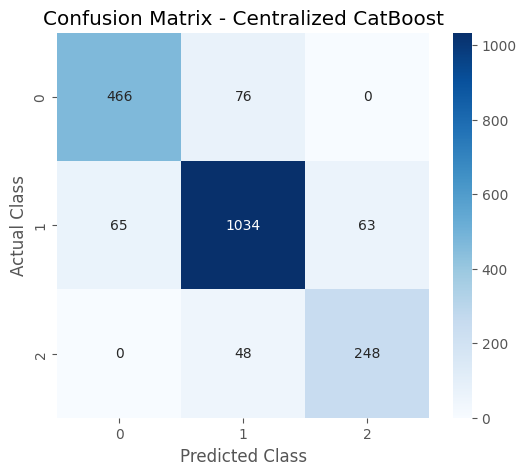

In [ ]:
# ============================================================
# Cell 14: Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.title("Confusion Matrix - Centralized CatBoost")

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

             Feature  Importance
8     Admission_Type   24.804122
0                Age   19.362623
9     Length_of_Stay   10.774449
2  Medical_Condition   10.067692
7     Smoking_Status    8.154319
3          Treatment    6.450806
4     Insurance_Type    5.929987
6             Region    5.820404
1             Gender    4.570364
5             Income    4.065233


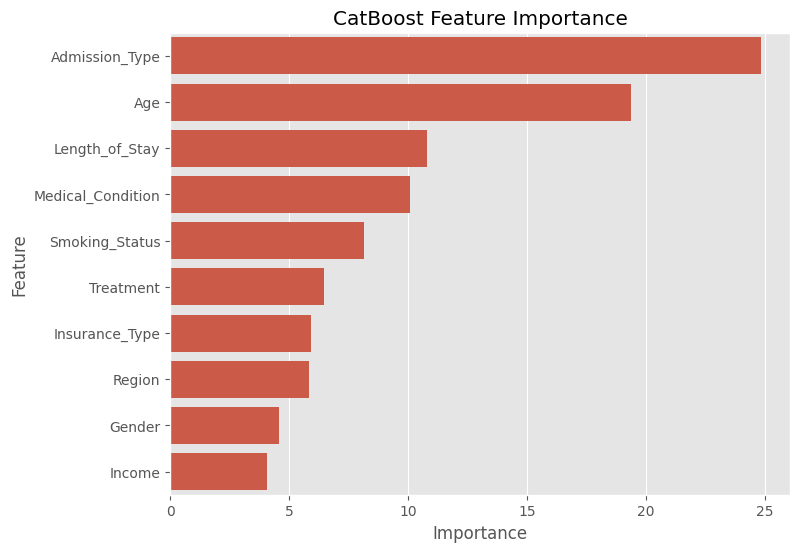

In [ ]:
# ============================================================
# Cell 15: Feature Importance Analysis
# ============================================================

feature_importance = pd.DataFrame({

    "Feature": X_train_smote.columns,

    "Importance": catboost_model.get_feature_importance()

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("CatBoost Feature Importance")

plt.show()

In [ ]:
# ============================================================
# Cell 16: Create Five Federated Clients
# ============================================================

# ------------------------------------------------------------
# Combine the training features and target variable into
# a single DataFrame.
#
# This makes it easier to divide the training data into
# multiple federated clients.
# ------------------------------------------------------------

train_data = X_train_smote.copy()

train_data["Outcome"] = y_train_smote.values

# ------------------------------------------------------------
# Shuffle the training dataset before splitting.
# ------------------------------------------------------------

train_data = train_data.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# ------------------------------------------------------------
# Split the training dataset equally among five clients.
# ------------------------------------------------------------

clients = np.array_split(train_data, 5)

print("=" * 60)
print("Federated Clients Created")
print("=" * 60)

for i, client in enumerate(clients):

    print(f"Client {i+1} : {len(client)} samples")

Federated Clients Created
Client 1 : 2790 samples
Client 2 : 2790 samples
Client 3 : 2790 samples
Client 4 : 2790 samples
Client 5 : 2790 samples


In [ ]:
# ============================================================
# Cell 17: Train Local CatBoost Models
# ============================================================

# ------------------------------------------------------------
# Train one CatBoost model for each federated client.
#
# Each client trains only on its own local dataset.
# No client shares its training data with others.
# ------------------------------------------------------------

local_models = []

for i, client in enumerate(clients):

    print("=" * 60)
    print(f"Training Client {i+1}")
    print("=" * 60)

    # -----------------------------------------
    # Separate Features and Target
    # -----------------------------------------

    X_client = client.drop("Outcome", axis=1)
    y_client = client["Outcome"]

    # -----------------------------------------
    # Initialize CatBoost
    # -----------------------------------------

    model = CatBoostClassifier(

        loss_function="MultiClass",

        iterations=500,

        learning_rate=0.05,

        depth=8,

        random_seed=42,

        verbose=False

    )

    # -----------------------------------------
    # Train Local Model
    # -----------------------------------------

    model.fit(

        X_client,

        y_client

    )

    local_models.append(model)

    print(f"✅ Client {i+1} Model Trained Successfully")

print("\n🎉 All Local Models Trained Successfully.")

Training Client 1
✅ Client 1 Model Trained Successfully
Training Client 2
✅ Client 2 Model Trained Successfully
Training Client 3
✅ Client 3 Model Trained Successfully
Training Client 4
✅ Client 4 Model Trained Successfully
Training Client 5
✅ Client 5 Model Trained Successfully

🎉 All Local Models Trained Successfully.


In [ ]:
# ============================================================
# Cell 18: Collect Prediction Probabilities from All Clients
# ============================================================

# ------------------------------------------------------------
# Each client uses its locally trained CatBoost model to
# predict the class probabilities for the common testing dataset.
#
# The prediction probabilities from all clients will be stored
# and later aggregated by the central server.
# ------------------------------------------------------------

client_probabilities = []

for i, model in enumerate(local_models):

    print("=" * 60)
    print(f"Client {i+1} Predicting...")
    print("=" * 60)

    # --------------------------------------------------------
    # Predict class probabilities
    # --------------------------------------------------------

    probabilities = model.predict_proba(X_test_smote)

    # Store probabilities
    client_probabilities.append(probabilities)

    print(f"Probability Matrix Shape : {probabilities.shape}")

print("\n✅ All clients generated prediction probabilities successfully.")

Client 1 Predicting...
Probability Matrix Shape : (2000, 3)
Client 2 Predicting...
Probability Matrix Shape : (2000, 3)
Client 3 Predicting...
Probability Matrix Shape : (2000, 3)
Client 4 Predicting...
Probability Matrix Shape : (2000, 3)
Client 5 Predicting...
Probability Matrix Shape : (2000, 3)

✅ All clients generated prediction probabilities successfully.


In [ ]:
# ============================================================
# Cell 19: Aggregate Client Prediction Probabilities
# ============================================================

# ------------------------------------------------------------
# The central server aggregates the prediction probabilities
# received from all federated clients by computing their average.
#
# This averaged probability matrix represents the global model's
# prediction for each test sample.
# ------------------------------------------------------------

# Average probabilities from all clients
global_probabilities = np.mean(client_probabilities, axis=0)

print("Global Probability Matrix Shape :", global_probabilities.shape)

print("\n✅ Probability aggregation completed successfully.")

Global Probability Matrix Shape : (2000, 3)

✅ Probability aggregation completed successfully.


In [ ]:
# ============================================================
# Cell 20: Generate Global Predictions
# ============================================================

# ------------------------------------------------------------
# Convert the averaged probability matrix into predicted classes.
#
# The class with the highest probability is selected as the
# final prediction for each patient.
# ------------------------------------------------------------

federated_predictions = np.argmax(global_probabilities, axis=1)

print("✅ Global predictions generated successfully.")

✅ Global predictions generated successfully.


In [ ]:
# ============================================================
# Cell 21: Evaluate Federated CatBoost
# ============================================================

federated_accuracy = accuracy_score(y_test, federated_predictions)

federated_precision = precision_score(
    y_test,
    federated_predictions,
    average="weighted"
)

federated_recall = recall_score(
    y_test,
    federated_predictions,
    average="weighted"
)

federated_f1 = f1_score(
    y_test,
    federated_predictions,
    average="weighted"
)

print("=" * 60)
print("Federated CatBoost Performance")
print("=" * 60)

print(f"Accuracy  : {federated_accuracy:.4f}")
print(f"Precision : {federated_precision:.4f}")
print(f"Recall    : {federated_recall:.4f}")
print(f"F1-Score  : {federated_f1:.4f}")

Federated CatBoost Performance
Accuracy  : 0.8640
Precision : 0.8651
Recall    : 0.8640
F1-Score  : 0.8644


In [ ]:
# ============================================================
# Cell 22: Apply Differential Privacy
# ============================================================

# ------------------------------------------------------------
# Apply Laplace noise to the prediction probabilities
# generated by each federated client.
#
# The noisy probabilities simulate privacy-preserving
# communication between clients and the central server.
# ------------------------------------------------------------

epsilon = 5.0          # Privacy budget
sensitivity = 1.0

noisy_client_probabilities = []

for i, probabilities in enumerate(client_probabilities):

    print("=" * 60)
    print(f"Applying Differential Privacy to Client {i+1}")
    print("=" * 60)

    noise = np.random.laplace(
        loc=0,
        scale=sensitivity/epsilon,
        size=probabilities.shape
    )

    noisy_probabilities = probabilities + noise

    # Ensure probabilities remain valid
    noisy_probabilities = np.clip(noisy_probabilities, 0, None)

    row_sum = noisy_probabilities.sum(axis=1, keepdims=True)

    noisy_probabilities = noisy_probabilities / row_sum

    noisy_client_probabilities.append(noisy_probabilities)

print("\n✅ Differential Privacy Applied Successfully.")

Applying Differential Privacy to Client 1
Applying Differential Privacy to Client 2
Applying Differential Privacy to Client 3
Applying Differential Privacy to Client 4
Applying Differential Privacy to Client 5

✅ Differential Privacy Applied Successfully.


In [ ]:
# ============================================================
# Cell 23: Aggregate Noisy Client Predictions
# ============================================================

global_noisy_probabilities = np.mean(
    noisy_client_probabilities,
    axis=0
)

dp_predictions = np.argmax(
    global_noisy_probabilities,
    axis=1
)

print("✅ Differential Privacy Aggregation Completed.")

✅ Differential Privacy Aggregation Completed.


In [ ]:
# ============================================================
# Cell 24: Evaluate Federated + Differential Privacy
# ============================================================

dp_accuracy = accuracy_score(y_test, dp_predictions)

dp_precision = precision_score(
    y_test,
    dp_predictions,
    average="weighted"
)

dp_recall = recall_score(
    y_test,
    dp_predictions,
    average="weighted"
)

dp_f1 = f1_score(
    y_test,
    dp_predictions,
    average="weighted"
)

print("=" * 60)
print("Federated + Differential Privacy Performance")
print("=" * 60)

print(f"Accuracy  : {dp_accuracy:.4f}")
print(f"Precision : {dp_precision:.4f}")
print(f"Recall    : {dp_recall:.4f}")
print(f"F1-Score  : {dp_f1:.4f}")

Federated + Differential Privacy Performance
Accuracy  : 0.8565
Precision : 0.8574
Recall    : 0.8565
F1-Score  : 0.8568


In [ ]:
# ============================================================
# Cell 25: Initialize Homomorphic Encryption Context
# ============================================================

# ------------------------------------------------------------
# Import the TenSEAL library and create a CKKS encryption
# context. The CKKS scheme supports approximate arithmetic,
# making it suitable for encrypted machine learning operations.
# ------------------------------------------------------------

import tenseal as ts

context = ts.context(
    ts.SCHEME_TYPE.CKKS,
    poly_modulus_degree=8192,
    coeff_mod_bit_sizes=[60, 40, 40, 60]
)

context.generate_galois_keys()

context.global_scale = 2**40

print("✅ Homomorphic Encryption Context Created Successfully.")

✅ Homomorphic Encryption Context Created Successfully.


In [ ]:
# ============================================================
# Cell 26: Encrypt Client Prediction Probabilities
# ============================================================

# ------------------------------------------------------------
# Encrypt the prediction probabilities generated by each
# federated client.
#
# Each probability vector is encrypted independently.
# ------------------------------------------------------------

encrypted_client_probabilities = []

for i, probabilities in enumerate(client_probabilities):

    print("=" * 60)
    print(f"Encrypting Client {i+1} Predictions")
    print("=" * 60)

    encrypted_rows = []

    for row in probabilities:

        encrypted_rows.append(
            ts.ckks_vector(context, row.tolist())
        )

    encrypted_client_probabilities.append(encrypted_rows)

print("\n✅ All Client Predictions Encrypted Successfully.")

Encrypting Client 1 Predictions
Encrypting Client 2 Predictions
Encrypting Client 3 Predictions
Encrypting Client 4 Predictions
Encrypting Client 5 Predictions

✅ All Client Predictions Encrypted Successfully.


In [ ]:
# ============================================================
# Cell 27: Aggregate Encrypted Prediction Probabilities
# ============================================================

# ------------------------------------------------------------
# The server aggregates encrypted prediction probabilities
# received from all federated clients.
#
# No decryption is performed during aggregation.
# ------------------------------------------------------------

encrypted_global_probabilities = []

num_samples = len(encrypted_client_probabilities[0])

for sample in range(num_samples):

    encrypted_sum = encrypted_client_probabilities[0][sample]

    for client in range(1, len(encrypted_client_probabilities)):

        encrypted_sum += encrypted_client_probabilities[client][sample]

    encrypted_global_probabilities.append(
        encrypted_sum * (1 / len(encrypted_client_probabilities))
    )

print("✅ Encrypted Aggregation Completed Successfully.")

✅ Encrypted Aggregation Completed Successfully.


In [ ]:
# ============================================================
# Cell 28: Decrypt Aggregated Predictions
# ============================================================

# ------------------------------------------------------------
# Decrypt the aggregated prediction probabilities to obtain
# the final probability vectors.
# ------------------------------------------------------------

he_probabilities = []

for vector in encrypted_global_probabilities:

    he_probabilities.append(vector.decrypt())

he_probabilities = np.array(he_probabilities)

print("Shape :", he_probabilities.shape)

print("✅ Decryption Completed Successfully.")

Shape : (2000, 3)
✅ Decryption Completed Successfully.


In [ ]:
# ============================================================
# Cell 29: Generate Final Predictions
# ============================================================

he_predictions = np.argmax(
    he_probabilities,
    axis=1
)

print("✅ Final Predictions Generated Successfully.")

✅ Final Predictions Generated Successfully.


In [ ]:
# ============================================================
# Cell 30: Evaluate Federated + Homomorphic Encryption
# ============================================================

he_accuracy = accuracy_score(y_test, he_predictions)

he_precision = precision_score(
    y_test,
    he_predictions,
    average="weighted"
)

he_recall = recall_score(
    y_test,
    he_predictions,
    average="weighted"
)

he_f1 = f1_score(
    y_test,
    he_predictions,
    average="weighted"
)

print("=" * 60)
print("Federated + Homomorphic Encryption Performance")
print("=" * 60)

print(f"Accuracy  : {he_accuracy:.4f}")
print(f"Precision : {he_precision:.4f}")
print(f"Recall    : {he_recall:.4f}")
print(f"F1-Score  : {he_f1:.4f}")

Federated + Homomorphic Encryption Performance
Accuracy  : 0.8640
Precision : 0.8651
Recall    : 0.8640
F1-Score  : 0.8644


In [ ]:
# ============================================================
# Cell 31: FedAvg Weighted Aggregation
# ============================================================

# ------------------------------------------------------------
# Calculate the contribution (weight) of each federated client
# based on the number of local training samples.
#
# FedAvg Weight:
#
# Weight = Client Samples / Total Samples
# ------------------------------------------------------------

total_samples = sum(len(client) for client in clients)

client_weights = [
    len(client) / total_samples
    for client in clients
]

print("=" * 60)
print("FedAvg Client Weights")
print("=" * 60)

for i, weight in enumerate(client_weights):

    print(f"Client {i+1} Weight : {weight:.4f}")

# ------------------------------------------------------------
# Perform weighted aggregation of prediction probabilities
# ------------------------------------------------------------

fedavg_probabilities = np.zeros_like(client_probabilities[0])

for weight, probabilities in zip(client_weights, client_probabilities):

    fedavg_probabilities += weight * probabilities

print("\n✅ FedAvg Aggregation Completed Successfully.")

FedAvg Client Weights
Client 1 Weight : 0.2000
Client 2 Weight : 0.2000
Client 3 Weight : 0.2000
Client 4 Weight : 0.2000
Client 5 Weight : 0.2000

✅ FedAvg Aggregation Completed Successfully.


In [ ]:
# ============================================================
# Cell 32: Generate FedAvg Predictions
# ============================================================

fedavg_predictions = np.argmax(
    fedavg_probabilities,
    axis=1
)

print("✅ FedAvg Predictions Generated Successfully.")

✅ FedAvg Predictions Generated Successfully.


In [ ]:
# ============================================================
# Cell 33: Evaluate FedAvg
# ============================================================

fedavg_accuracy = accuracy_score(
    y_test,
    fedavg_predictions
)

fedavg_precision = precision_score(
    y_test,
    fedavg_predictions,
    average="weighted"
)

fedavg_recall = recall_score(
    y_test,
    fedavg_predictions,
    average="weighted"
)

fedavg_f1 = f1_score(
    y_test,
    fedavg_predictions,
    average="weighted"
)

print("=" * 60)
print("FedAvg Performance")
print("=" * 60)

print(f"Accuracy  : {fedavg_accuracy:.4f}")
print(f"Precision : {fedavg_precision:.4f}")
print(f"Recall    : {fedavg_recall:.4f}")
print(f"F1-Score  : {fedavg_f1:.4f}")

FedAvg Performance
Accuracy  : 0.8640
Precision : 0.8651
Recall    : 0.8640
F1-Score  : 0.8644


In [ ]:
# ============================================================
# DP + FedAvg Aggregation
# ============================================================

# Initialize probability matrix
dp_fedavg_probabilities = np.zeros_like(noisy_client_probabilities[0])

# Weighted FedAvg aggregation
for weight, probabilities in zip(client_weights,
                                 noisy_client_probabilities):

    dp_fedavg_probabilities += weight * probabilities

print("✅ DP + FedAvg Aggregation Completed Successfully.")

✅ DP + FedAvg Aggregation Completed Successfully.


In [ ]:
dp_fedavg_predictions = np.argmax(
    dp_fedavg_probabilities,
    axis=1
)

In [ ]:
dp_fedavg_accuracy = accuracy_score(
    y_test,
    dp_fedavg_predictions
)

dp_fedavg_precision = precision_score(
    y_test,
    dp_fedavg_predictions,
    average="weighted"
)

dp_fedavg_recall = recall_score(
    y_test,
    dp_fedavg_predictions,
    average="weighted"
)

dp_fedavg_f1 = f1_score(
    y_test,
    dp_fedavg_predictions,
    average="weighted"
)

print("="*60)
print("CatBoost + DP + FedAvg Performance")
print("="*60)

print(f"Accuracy  : {dp_fedavg_accuracy:.4f}")
print(f"Precision : {dp_fedavg_precision:.4f}")
print(f"Recall    : {dp_fedavg_recall:.4f}")
print(f"F1-Score  : {dp_fedavg_f1:.4f}")

CatBoost + DP + FedAvg Performance
Accuracy  : 0.8565
Precision : 0.8574
Recall    : 0.8565
F1-Score  : 0.8568


In [ ]:
# ============================================================
# HE + FedAvg Aggregation
# ============================================================

he_fedavg_probabilities = []

num_samples = len(encrypted_client_probabilities[0])

for sample in range(num_samples):

    encrypted_sum = encrypted_client_probabilities[0][sample] * client_weights[0]

    for client in range(1, len(encrypted_client_probabilities)):

        encrypted_sum += (
            encrypted_client_probabilities[client][sample]
            * client_weights[client]
        )

    he_fedavg_probabilities.append(encrypted_sum)

print("✅ HE + FedAvg Aggregation Completed Successfully.")

✅ HE + FedAvg Aggregation Completed Successfully.


In [ ]:
he_fedavg_matrix = []

for vector in he_fedavg_probabilities:

    he_fedavg_matrix.append(vector.decrypt())

he_fedavg_matrix = np.array(he_fedavg_matrix)

In [ ]:
he_fedavg_predictions = np.argmax(
    he_fedavg_matrix,
    axis=1
)

In [ ]:
he_fedavg_accuracy = accuracy_score(
    y_test,
    he_fedavg_predictions
)

he_fedavg_precision = precision_score(
    y_test,
    he_fedavg_predictions,
    average="weighted"
)

he_fedavg_recall = recall_score(
    y_test,
    he_fedavg_predictions,
    average="weighted"
)

he_fedavg_f1 = f1_score(
    y_test,
    he_fedavg_predictions,
    average="weighted"
)

print("="*60)
print("CatBoost + HE + FedAvg Performance")
print("="*60)

print(f"Accuracy  : {he_fedavg_accuracy:.4f}")
print(f"Precision : {he_fedavg_precision:.4f}")
print(f"Recall    : {he_fedavg_recall:.4f}")
print(f"F1-Score  : {he_fedavg_f1:.4f}")

CatBoost + HE + FedAvg Performance
Accuracy  : 0.8635
Precision : 0.8646
Recall    : 0.8635
F1-Score  : 0.8639
